In [16]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris, load_digits
from sklearn.decomposition import PCA as sklearnpca
from sklearn.preprocessing import StandardScaler


# THE MATH BEHIND PCA


### Goal: Reduce the number of features while keeping as much
####       information (variance) as possible.

### Steps:
   1. Standardize the data (mean=0, std=1)
   2. Compute the covariance matrix: C = (1/n) * X.T @ X
   3. Find eigenvalues and eigenvectors of C
   4. Sort eigenvectors by eigenvalue (largest first)
   5. Project data onto top K eigenvectors

### Why it works:
   Eigenvectors point in the directions of maximum variance.
   The first eigenvector captures the most variance,
   the second captures the next most, and so on.

### Result: K new features (components) that are:
   - Uncorrelated with each other
   - Ordered by how much variance they explain
      - Linear combinations of the original features


PCA summary:
    1. Standardize data
    2. Compute covariance matrix
    3. Find eigenvalues and eigenvectors
    4. Sort by eigenvalue (variance explained)
    5. Project data onto top K components

In [35]:
class PCAScratch:

    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.eigenvalues = None
        self.explained_variance = None
        self.mean = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        n_samples = X.shape[0]
        cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        self.eigenvalues = eigenvalues
        self.components = eigenvectors[:, :self.n_components]

        total_variance = np.sum(eigenvalues)
        self.explained_variance = eigenvalues[:self.n_components] / total_variance
        self.explained_variance_all = eigenvalues / total_variance

        return self
        
    def transform(self, X):
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_transformed):
        return X_transformed @ self.components.T + self.mean
        

In [36]:
# Loading the data
iris = load_iris()
X = iris.data
y = iris.target

In [37]:
X.shape

(150, 4)

In [38]:
y.shape

(150,)

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
print(X_scaled)

[[-9.00681170e-01  1.01900435e+00 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00 -1.31979479e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.38535265e+00  3.28414053e-01 -1.39706395e+00 -1.31544430e+00]
 [-1.50652052e+00  9.82172869e-02 -1.28338910e+00 -1.31544430e+00]
 [-1.02184904e+00  1.24920112e+00 -1.34022653e+00 -1.31544430e+00]
 [-5.37177559e-01  1.93979142e+00 -1.16971425e+00 -1.05217993e+00]
 [-1.50652052e+00  7.88807586e-01 -1.34022653e+00 -1.18381211e+00]
 [-1.02184904e+00  7.88807586e-01 -1.28338910e+00 -1.31544430e+00]
 [-1.74885626e+00 -3.62176246e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00  9.82172869e-02 -1.28338910e+00 -1.44707648e+00]
 [-5.37177559e-01  1.47939788e+00 -1.28338910e+00 -1.31544430e+00]
 [-1.26418478e+00  7.88807586e-01 -1.22655167e+00 -1.31544430e+00]
 [-1.26418478e+00 -1.31979479e-01 -1.34022653e+00 -1.44707648e+00]
 [-1.87002413e+00 -1.31979479e-01 -1.51073881e+00 -1.44707648e+00]
 [-5.25060772e-02  2.16998818e+00 -1.45390138e+00 -1.31544430e

In [41]:
# Moving From 4D to 2D
pca =PCAScratch (n_components
                 =2)
X_pca = pca.fit_transform(X_scaled)

In [42]:
print(X_pca)

[[ 2.26470281  0.4800266 ]
 [ 2.08096115 -0.67413356]
 [ 2.36422905 -0.34190802]
 [ 2.29938422 -0.59739451]
 [ 2.38984217  0.64683538]
 [ 2.07563095  1.48917752]
 [ 2.44402884  0.0476442 ]
 [ 2.23284716  0.22314807]
 [ 2.33464048 -1.11532768]
 [ 2.18432817 -0.46901356]
 [ 2.1663101   1.04369065]
 [ 2.32613087  0.13307834]
 [ 2.2184509  -0.72867617]
 [ 2.6331007  -0.96150673]
 [ 2.1987406   1.86005711]
 [ 2.26221453  2.68628449]
 [ 2.2075877   1.48360936]
 [ 2.19034951  0.48883832]
 [ 1.898572    1.40501879]
 [ 2.34336905  1.12784938]
 [ 1.914323    0.40885571]
 [ 2.20701284  0.92412143]
 [ 2.7743447   0.45834367]
 [ 1.81866953  0.08555853]
 [ 2.22716331  0.13725446]
 [ 1.95184633 -0.62561859]
 [ 2.05115137  0.24216355]
 [ 2.16857717  0.52714953]
 [ 2.13956345  0.31321781]
 [ 2.26526149 -0.3377319 ]
 [ 2.14012214 -0.50454069]
 [ 1.83159477  0.42369507]
 [ 2.61494794  1.79357586]
 [ 2.44617739  2.15072788]
 [ 2.10997488 -0.46020184]
 [ 2.2078089  -0.2061074 ]
 [ 2.04514621  0.66155811]
 

In [44]:
for i, var, in enumerate(pca.explained_variance):
    print(f" PCA{i+1}: {var*100:.1f}%")
print(f" Total: {sum(pca.explained_variance)*100:.1f}%")

 PCA1: 73.0%
 PCA2: 22.9%
 Total: 95.8%


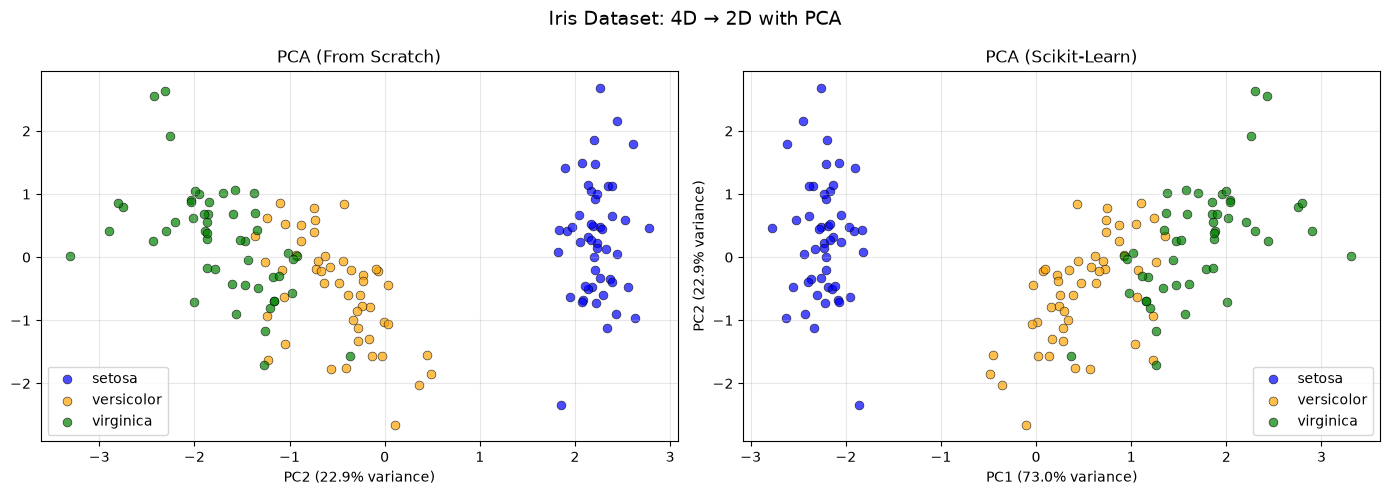

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['blue', 'orange', 'green']
for i, (cls, name) in enumerate(zip([0, 1, 2], iris.target_names)):
    mask = y == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i],
    label=name, alpha=0.7, s=40, edgecolors='k', linewidths=0.5)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance[0]*100:.1f}% variance)')
axes[0].set_xlabel(f'PC2 ({pca.explained_variance[1]*100:.1f}% variance)')
axes[0].set_title('PCA (From Scratch)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sklearn_pca = sklearnpca(n_components=2)
X_sklearn = sklearn_pca.fit_transform(X_scaled)

for i, (cls, name) in enumerate(zip([0, 1, 2], iris.target_names)):
    mask = y == cls
    axes[1].scatter(X_sklearn[mask, 0], X_sklearn[mask, 1], c=colors[i],
                     label=name, alpha=0.7, s=40, edgecolors='k', linewidths=0.5)
axes[1].set_xlabel(f'PC1 ({sklearn_pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({sklearn_pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('PCA (Scikit-Learn)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Iris Dataset: 4D → 2D with PCA', fontsize=14)
plt.tight_layout()
plt.savefig('pca_iris.png', dpi=150, bbox_inches='tight')
plt.show()

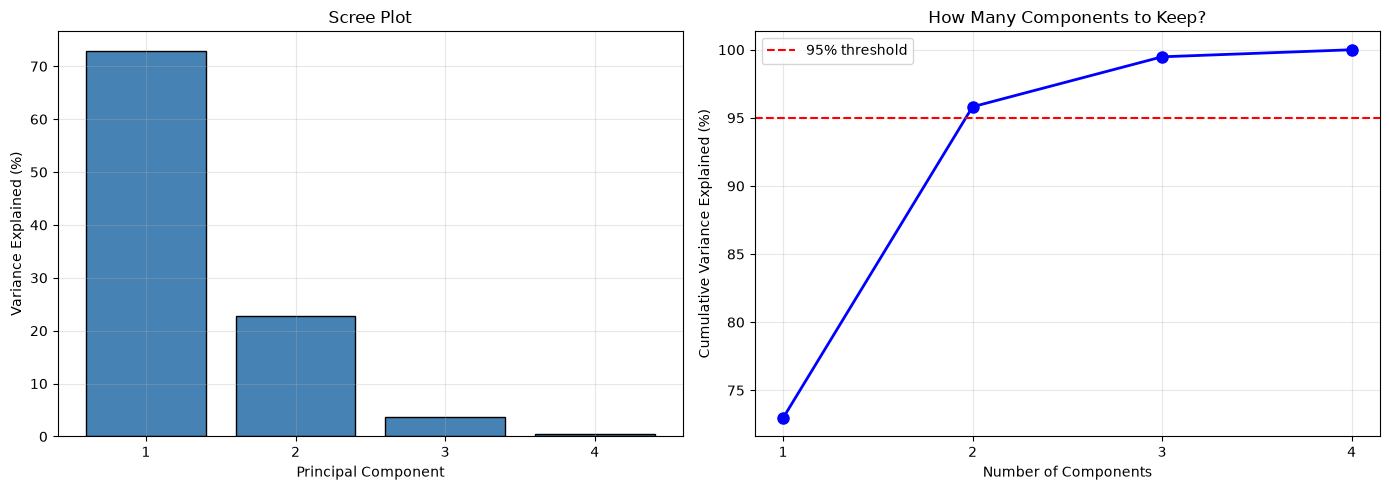


2 components capture 95.8% of variance
3 components capture 99.5% of variance


In [52]:

# Scree Plot

pca_full = PCAScratch(n_components=4)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear  variance
axes[0].bar(range(1, 5), pca_full.explained_variance_all[:4] * 100, 
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 5))
axes[0].grid(True, alpha=0.3)

# Cumulative variance
cumulative = np.cumsum(pca_full.explained_variance_all[:4]) * 100
axes[1].plot(range(1, 5), cumulative, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('How Many Components to Keep?')
axes[1].set_xticks(range(1, 5))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n2 components capture {cumulative[1]:.1f}% of variance")
print(f"3 components capture {cumulative[2]:.1f}% of variance")

Original: 64 features (8x8 pixel images)
After PCA: 2 features
Variance retained: 21.6%


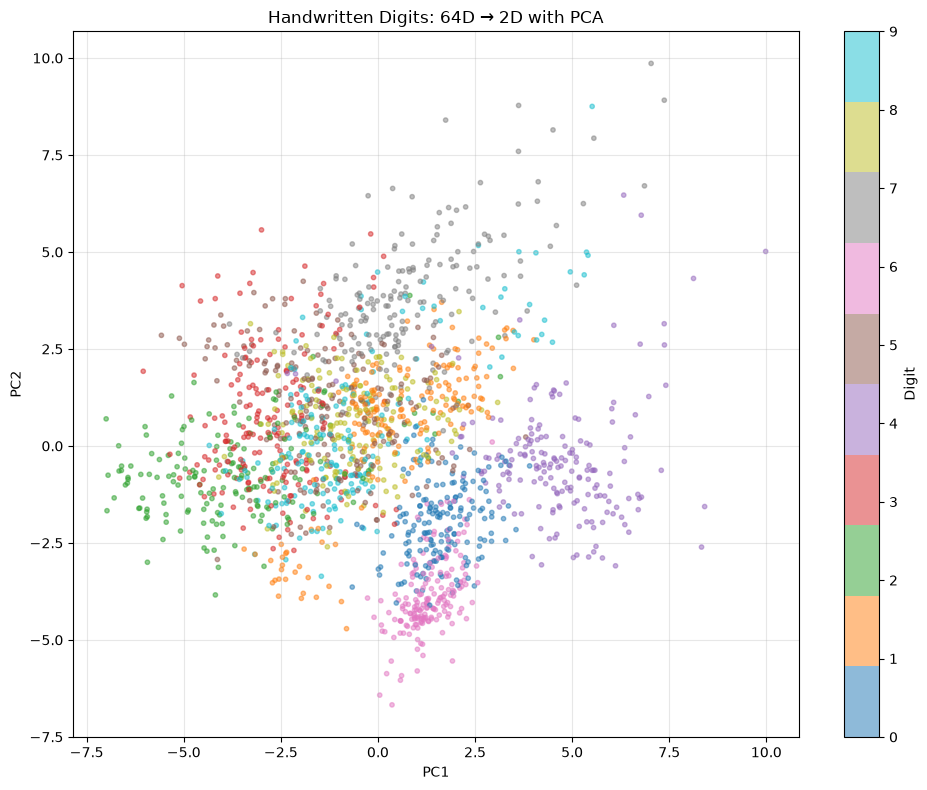

In [55]:
# Applying to the Digits Datasets (64D → 2D)

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Standardize
X_digits_scaled = StandardScaler().fit_transform(X_digits)

# PCA
pca_digits = PCAScratch(n_components=2)
X_digits_2d = pca_digits.fit_transform(X_digits_scaled)

print(f"Original: {X_digits.shape[1]} features (8x8 pixel images)")
print(f"After PCA: {X_digits_2d.shape[1]} features")
print(f"Variance retained: {sum(pca_digits.explained_variance)*100:.1f}%")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_digits_2d[:, 0], X_digits_2d[:, 1], 
                       c=y_digits, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Digit')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Handwritten Digits: 64D → 2D with PCA')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_digits.png', dpi=150, bbox_inches='tight')
plt.show()


# PCA FROM SCRATCH — COMPLETE
What was built:
  - PCAScratch class using only NumPy
  - Covariance matrix computation
  - Eigendecomposition for finding principal components
  - Variance explained calculation
  - fit(), transform(), fit_transform(), inverse_transform()

Key concepts:
  - PCA finds directions of maximum variance
  - First PC captures most variance, second captures next most
  - Scree plot helps decide how many components to keep
  - 95% variance threshold is a common rule of thumb
  - PCA is used for visualization, noise reduction, and preprocessing

Verified against scikit-learn: results match.
